# ✈️ Flight-Focused Airline Operations Delay EDA (2024)

This notebook performs exploratory data analysis on the **2024 merged flight dataset** with a deliberate focus on the **flight operations side** of the project.  

The notebook is designed to answer five flight-centered questions:

- how often delays happen (`IS_Delay`)
- how severe delays are (`delay_in_minutes`)
- when delays cluster across the year, month, week, and day
- which airlines, origins, and routes are less reliable
- which operational delay reasons contribute the most delay burden

## Why this EDA matters
This analysis supports the next stage of the project: predicting whether a flight will be delayed by **more than 15 minutes**.  
It is built to feed:
- SQL KPI analysis
- flight-side storytelling in the final presentation
- feature thinking for the delay-prediction model


## 0. Setup and scope notes

**Key analytical choices used in this notebook**
- The source file is the merged project dataset, but this notebook stays focused on the **flight side** of the analysis.
- The main delay measures are `IS_Delay` and `delay_in_minutes`.
- `IS_Delay = 1` means **delay greater than 15 minutes**.
- `Season`, `Departure_Hour`, weekday, month, and airline names are treated as engineered analytical features.
- Airline, city, and route rankings use **minimum-volume thresholds** where appropriate so that conclusions are not driven by tiny groups.
- Weather fields may exist in the file, but detailed weather-impact EDA is intentionally left to the separate teammate notebook.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cycler import cycler
from pathlib import Path

PALETTE = ["#0F4C81", "#FF6B6B", "#2A9D8F", "#E9C46A", "#9B5DE5", "#F4A261", "#457B9D", "#8D99AE"]
ACCENT = "#FF6B6B"
DARK = "#0F4C81"
GREEN = "#2A9D8F"
GOLD = "#E9C46A"
PURPLE = "#9B5DE5"
ORANGE = "#F4A261"

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def safe_pct(n, d):
    return np.nan if d == 0 else n / d

def add_bar_labels(ax, fmt='{:.1%}', pad=3, fontsize=9):
    for p in ax.patches:
        val = p.get_width() if p.get_width() > p.get_height() else p.get_height()
        if pd.isna(val):
            continue
        label = fmt.format(val) if '%' in fmt else fmt.format(val)
        if p.get_width() > p.get_height():
            ax.annotate(label, (p.get_width(), p.get_y() + p.get_height()/2),
                        xytext=(pad, 0), textcoords='offset points', va='center', fontsize=fontsize)
        else:
            ax.annotate(label, (p.get_x() + p.get_width()/2, p.get_height()),
                        xytext=(0, pad), textcoords='offset points', ha='center', fontsize=fontsize)


## 1. Load data and inspect structure

This section confirms the size of the dataset, the available columns, and the basic data types before any interpretation begins.

In [2]:
from pathlib import Path
import pandas as pd

possible_paths = [
    Path("../../Merged_Data/merged_flights.csv"),
    Path("../Merged_Data/merged_flights.csv"),
    Path("Merged_Data/merged_flights.csv"),
    Path("merged_flights.csv"),
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError(
        "merged_flights.csv not found. Expected it in ../../Merged_Data/ or another listed fallback path."
    )

print("Using file:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH, low_memory=False)


Using file: /Users/saritaaaaa/Downloads/STT811-Applied Stat/Project/Flight_Delay_Prediction-main/Merged_Data/merged_flights.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343443 entries, 0 to 1343442
Data columns (total 37 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   year                  1343443 non-null  int64  
 1   month                 1343443 non-null  int64  
 2   day_of_month          1343443 non-null  int64  
 3   day_of_week           1343443 non-null  int64  
 4   fl_date               1343443 non-null  object 
 5   op_unique_carrier     1343443 non-null  object 
 6   op_carrier_fl_num     1343443 non-null  float64
 7   origin_city           1343443 non-null  object 
 8   origin_state          1343443 non-null  object 
 9   dest_city             1343443 non-null  object 
 10  dest_state            1343443 non-null  object 
 11  crs_dep_time          1343443 non-null  int64  
 12  dep_time              1343443 non-null  float64
 13  dep_delay             1343443 non-null  float64
 14  crs_arr_time          1343443 non-

In [4]:
df.columns.tolist()

['year',
 'month',
 'day_of_month',
 'day_of_week',
 'fl_date',
 'op_unique_carrier',
 'op_carrier_fl_num',
 'origin_city',
 'origin_state',
 'dest_city',
 'dest_state',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'crs_arr_time',
 'arr_time',
 'arr_delay',
 'cancelled',
 'crs_elapsed_time',
 'actual_elapsed_time',
 'air_time',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'delay_in_minutes',
 'IS_Delay',
 'Season',
 'Departure_Hour',
 'Temperature_C',
 'Humidity_pct',
 'Precipitation_mm',
 'Wind_Speed_kmh',
 'Date',
 'Time',
 'Weather_Data_Present']

## 2. Data quality and preparation

A strong EDA should document what was cleaned, derived, and treated carefully before interpretation.  
This section checks:

- missing values
- duplicate rows
- data types
- derived **flight-focused** fields used later in analysis


In [5]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)
missing["missing_pct"] = 100 * missing["missing_count"] / len(df)
missing[missing["missing_count"] > 0].head(15)

,missing_count,missing_pct
Time,1234604,91.898503
Date,1234604,91.898503
Wind_Speed_kmh,1234604,91.898503
Precipitation_mm,1234604,91.898503
Humidity_pct,1234604,91.898503
Temperature_C,1234604,91.898503


In [6]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count:,}")

Duplicate rows: 0


In [7]:
# Type handling and derived fields
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

# Ensure key analytic fields are numeric where expected
for col in [
    "IS_Delay", "delay_in_minutes", "Departure_Hour", "month", "day_of_week",
    "crs_elapsed_time", "actual_elapsed_time", "air_time",
    "carrier_delay", "weather_delay", "nas_delay", "security_delay", "late_aircraft_delay",
    "cancelled"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create route for route-level analysis
df["route"] = df["origin_city"].astype(str) + " → " + df["dest_city"].astype(str)

# Ordered categories for cleaner plots
season_order = ["Winter", "Spring", "Summer", "Fall"]
weekday_map = {
    1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu",
    5: "Fri", 6: "Sat", 7: "Sun"
}
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

airline_map = {
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue Airways",
    "DL": "Delta Air Lines",
    "F9": "Frontier Airlines",
    "G4": "Allegiant Air",
    "HA": "Hawaiian Airlines",
    "NK": "Spirit Airlines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines",
    "OO": "SkyWest Airlines",
    "MQ": "Envoy Air",
    "OH": "PSA Airlines",
    "YV": "Mesa Airlines",
    "YX": "Republic Airways",
    "9E": "Endeavor Air",
    "EV": "ExpressJet Airlines",
    "QX": "Horizon Air",
    "PT": "Piedmont Airlines",
    "C5": "CommutAir"
}

df["weekday_name"] = df["day_of_week"].map(weekday_map)
df["month_name"] = df["month"].map(month_map)
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
df["airline_name"] = df["op_unique_carrier"].map(airline_map).fillna(df["op_unique_carrier"])
df["week_start"] = df["fl_date"].dt.to_period("W").apply(lambda r: r.start_time) if "fl_date" in df.columns else pd.NaT
df["day_of_year"] = df["fl_date"].dt.dayofyear

# Masks used throughout the notebook
operated_mask = df["cancelled"].fillna(0).eq(0) if "cancelled" in df.columns else pd.Series(True, index=df.index)
delayed_mask = df["IS_Delay"].fillna(0).eq(1)

print("Prepared fields added: route, weekday_name, month_name, airline_name, week_start")


Prepared fields added: route, weekday_name, month_name, airline_name, week_start


### Data preparation notes
- The file is already merged, but this notebook emphasizes the **flight-side operational variables**.
- Delay-related numeric fields remain useful because they describe operational outcomes and delay severity.
- Airline names, route labels, calendar features, and ordered categories are prepared to make the visuals cleaner and easier to present.
- Cancellation is checked carefully instead of assuming it is analytically useful in this final file.


## 3. Overall operational KPI snapshot

This section gives a compact summary of flight performance in the file.  
Because this notebook is flight-focused, the KPI view concentrates on:

- total flights
- delayed flights
- delay rate
- average delay severity in minutes
- median delay severity in minutes

These KPIs establish scale first, then show how common and how severe delay is in the dataset.


In [8]:
total_flights = len(df)
delayed_flights = int(df["IS_Delay"].fillna(0).sum())
delay_rate = safe_pct(delayed_flights, total_flights)

avg_delay_minutes = df.loc[operated_mask, "delay_in_minutes"].mean()
median_delay_minutes = df.loc[operated_mask, "delay_in_minutes"].median()

kpi = pd.DataFrame({
    "Metric": [
        "Total flights",
        "Delayed flights (IS_Delay = 1)",
        "Delay rate",
        "Average delay in minutes",
        "Median delay in minutes"
    ],
    "Value": [
        f"{total_flights:,}",
        f"{delayed_flights:,}",
        f"{delay_rate:.2%}" if pd.notna(delay_rate) else "NA",
        f"{avg_delay_minutes:.2f}" if pd.notna(avg_delay_minutes) else "NA",
        f"{median_delay_minutes:.2f}" if pd.notna(median_delay_minutes) else "NA"
    ]
})
kpi

,Metric,Value
0,Total flights,"1,343,443"
1,Delayed flights (IS_Delay = 1),"393,696"
2,Delay rate,29.31%
3,Average delay in minutes,19.86
4,Median delay in minutes,-8.00


**KPI readout:** This snapshot establishes the scale of the operation first, then summarizes how often delay occurs and how severe it tends to be.  
It gives a clean flight-side summary without mixing in weather-specific interpretation.


## 4. Delay distribution and target balance

This section explores the shape of **overall delay behavior**.  
Instead of centering the notebook on separate departure and arrival delay views, the analysis focuses on:

- `delay_in_minutes` as the main severity measure
- `IS_Delay` as the binary target used later in modeling

This helps show:
- whether most flights are near on time
- how heavy the tail of severe delays is
- whether the classification target is imbalanced


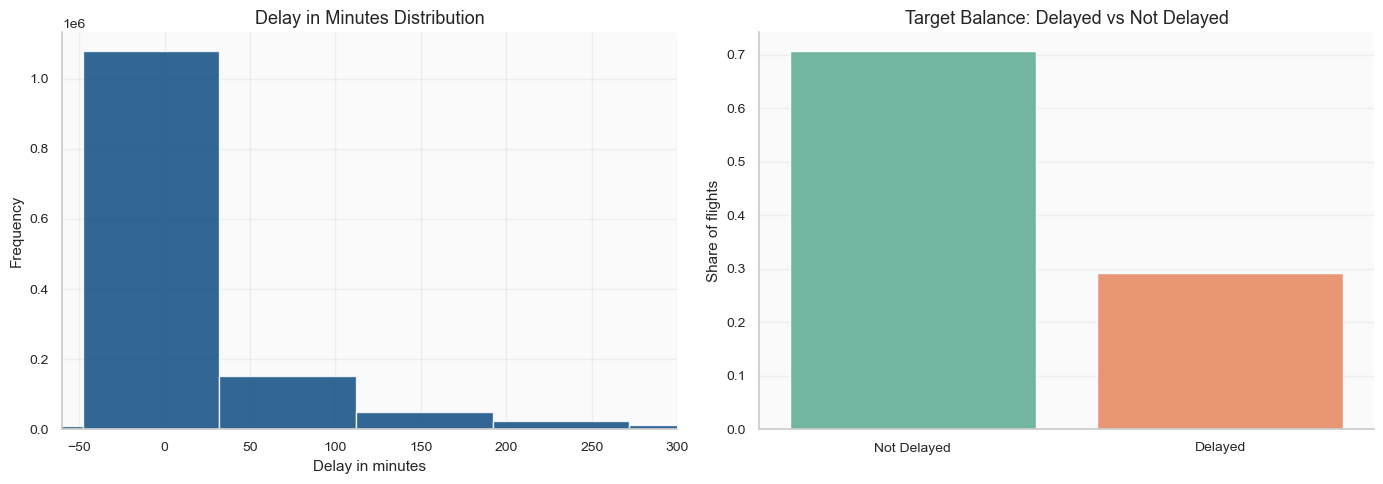

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df.loc[operated_mask, "delay_in_minutes"].dropna(), bins=80, color=DARK, alpha=0.85, edgecolor='white')
axes[0].set_title("Delay in Minutes Distribution")
axes[0].set_xlabel("Delay in minutes")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(-60, 300)

delay_balance = (
    df["IS_Delay"]
      .fillna(0)
      .astype(int)
      .value_counts(normalize=True)
      .rename_axis("IS_Delay")
      .reset_index(name="share")
      .sort_values("IS_Delay")
)
delay_balance["label"] = delay_balance["IS_Delay"].map({0: "Not Delayed", 1: "Delayed"})

sns.barplot(data=delay_balance, x="label", y="share", ax=axes[1], palette="Set2")
axes[1].set_title("Target Balance: Delayed vs Not Delayed")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of flights")

plt.tight_layout()
plt.show()


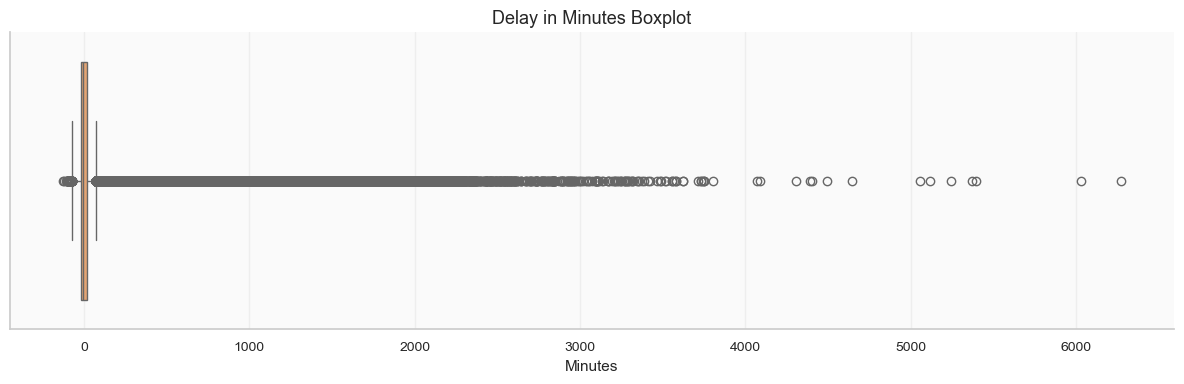

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(x=df.loc[operated_mask, "delay_in_minutes"], ax=ax, color=ORANGE)
ax.set_title("Delay in Minutes Boxplot")
ax.set_xlabel("Minutes")

plt.tight_layout()
plt.show()


In [11]:
delay_summary = df.loc[operated_mask, ["delay_in_minutes"]].describe().T
delay_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]


,mean,std,min,25%,50%,75%,max
delay_in_minutes,19.859015,113.303937,-128.0,-20.0,-8.0,17.0,6273.0


## 5. Time-based operational patterns

Flight reliability changes over the calendar and across the day.  
This section studies:

- month
- week
- season
- day of week
- departure hour

The aim is to identify **when** delays are most common and when delay severity becomes worse.


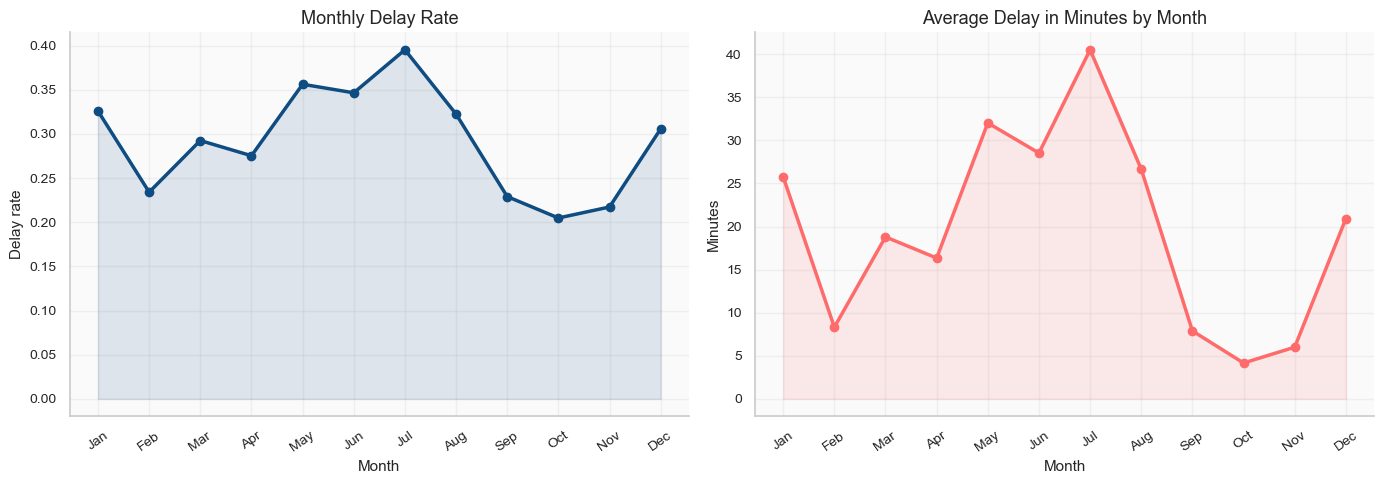

,month,month_name,flights,delay_rate,avg_delay_minutes
0,1,Jan,100691,0.325858,25.760197
1,2,Feb,98937,0.234068,8.322155
2,3,Mar,112887,0.292469,18.794290
3,4,Apr,111565,0.275292,16.345574
4,5,May,115740,0.356212,32.021946
5,6,Jun,115908,0.346508,28.529661
6,7,Jul,118347,0.395219,40.507888
7,8,Aug,116622,0.322418,26.648188
8,9,Sep,111559,0.229054,7.888014
9,10,Oct,117461,0.204808,4.166370


In [12]:
monthly = (
    df.groupby(["month", "month_name"], as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("month")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly["month_name"], monthly["delay_rate"], marker="o", linewidth=2.5, color=DARK)
axes[0].fill_between(monthly["month_name"], monthly["delay_rate"], color=DARK, alpha=0.12)
axes[0].set_title("Monthly Delay Rate")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Delay rate")
axes[0].tick_params(axis='x', rotation=35)

axes[1].plot(monthly["month_name"], monthly["avg_delay_minutes"], marker="o", linewidth=2.5, color=ACCENT)
axes[1].fill_between(monthly["month_name"], monthly["avg_delay_minutes"], color=ACCENT, alpha=0.12)
axes[1].set_title("Average Delay in Minutes by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

monthly


### Delayed flights by month

The chart below looks at **delay frequency in absolute terms**, not just delay rate. This is useful because a month can have a moderate rate but still contribute a large number of delayed flights if flight volume is high.


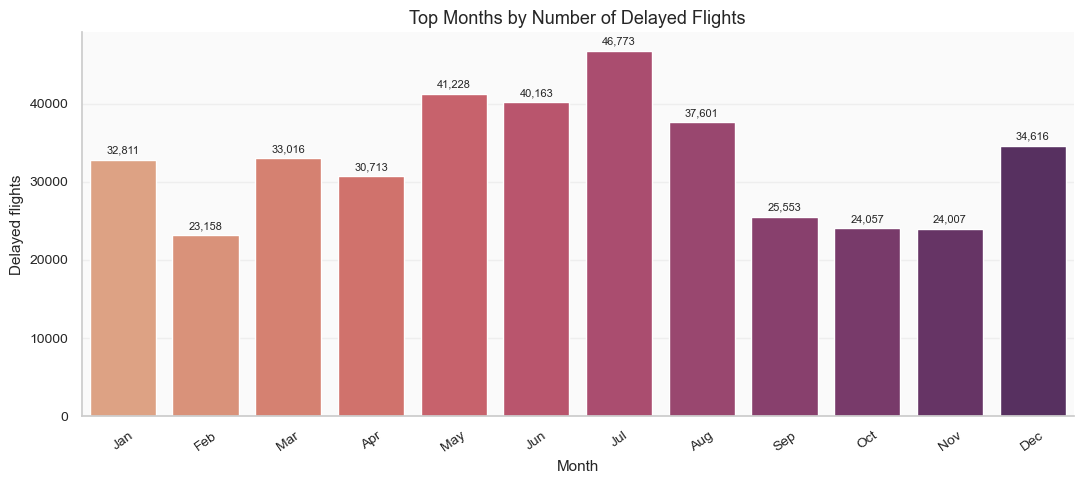

,month,month_name,delayed_flights
6,7,Jul,46773
4,5,May,41228
5,6,Jun,40163
7,8,Aug,37601
11,12,Dec,34616
2,3,Mar,33016


In [13]:
monthly_delay_counts = (
    df[df["IS_Delay"] == 1]
      .groupby(["month", "month_name"], as_index=False)
      .size()
      .rename(columns={"size": "delayed_flights"})
      .sort_values("month")
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=monthly_delay_counts, x="month_name", y="delayed_flights", palette="flare")
plt.title("Top Months by Number of Delayed Flights")
plt.xlabel("Month")
plt.ylabel("Delayed flights")
plt.xticks(rotation=35)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

monthly_delay_counts.sort_values("delayed_flights", ascending=False).head(6)


### Weekly delay trend

Monthly charts show the broad pattern, but weekly aggregation reveals shorter-term spikes and makes the trend feel more operational.


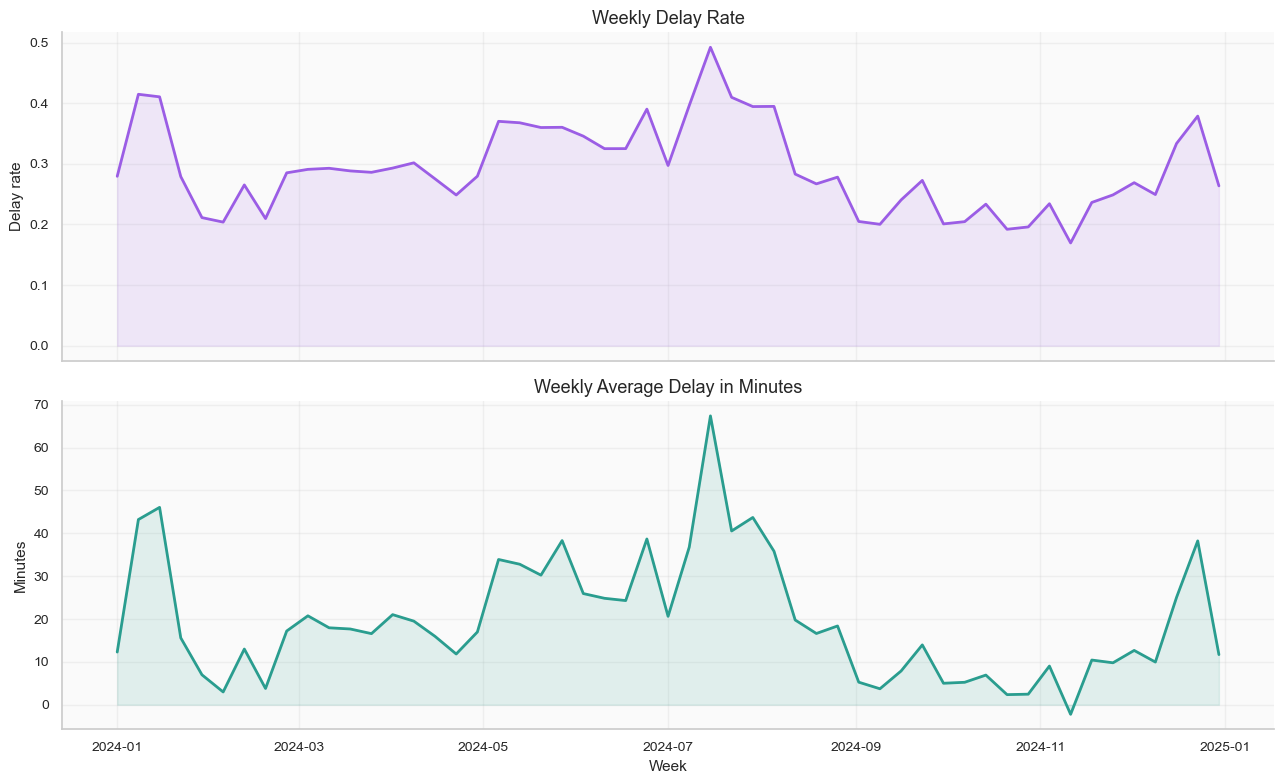

In [14]:
weekly = (
    df.dropna(subset=["week_start"])
      .groupby("week_start", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("week_start")
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(weekly["week_start"], weekly["delay_rate"], color=PURPLE, linewidth=2)
axes[0].fill_between(weekly["week_start"], weekly["delay_rate"], color=PURPLE, alpha=0.12)
axes[0].set_title("Weekly Delay Rate")
axes[0].set_ylabel("Delay rate")

axes[1].plot(weekly["week_start"], weekly["avg_delay_minutes"], color=GREEN, linewidth=2)
axes[1].fill_between(weekly["week_start"], weekly["avg_delay_minutes"], color=GREEN, alpha=0.12)
axes[1].set_title("Weekly Average Delay in Minutes")
axes[1].set_ylabel("Minutes")
axes[1].set_xlabel("Week")

plt.tight_layout()
plt.show()


**Weekly insight:** Weekly aggregation is useful because it reveals shorter operational surges that monthly averages can hide.  
If the line shows repeated spikes, that supports the idea that delays are not random noise and may be linked to recurring congestion, schedule pressure, or broader disruption events.

### Month × day-of-week delay heatmap

This view helps show **when delays cluster in the calendar** by combining month and weekday rather than looking at each time variable separately.


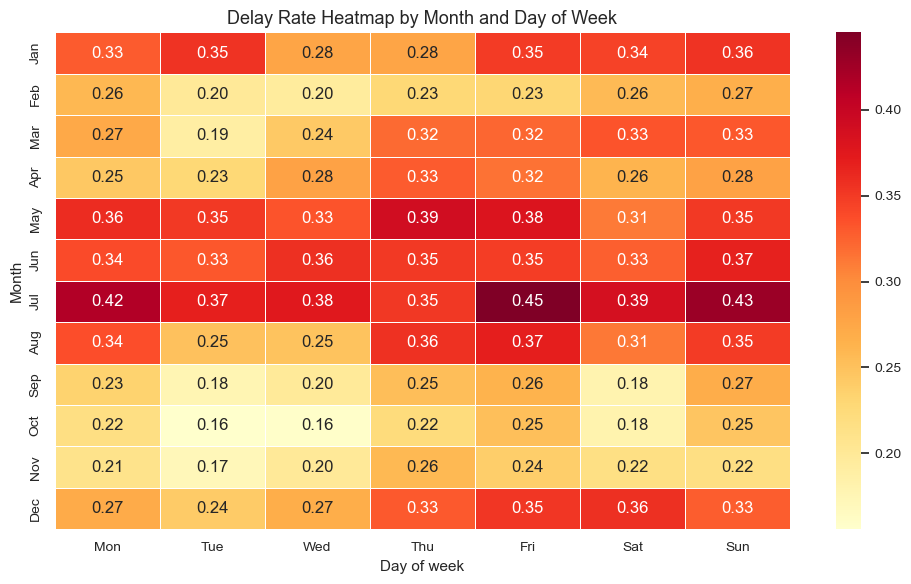

In [15]:
month_weekday_heat = (
    df.pivot_table(index="month_name", columns="weekday_name", values="IS_Delay", aggfunc="mean")
      .reindex(index=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
               columns=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
)

plt.figure(figsize=(10, 6))
sns.heatmap(month_weekday_heat, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Delay Rate Heatmap by Month and Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


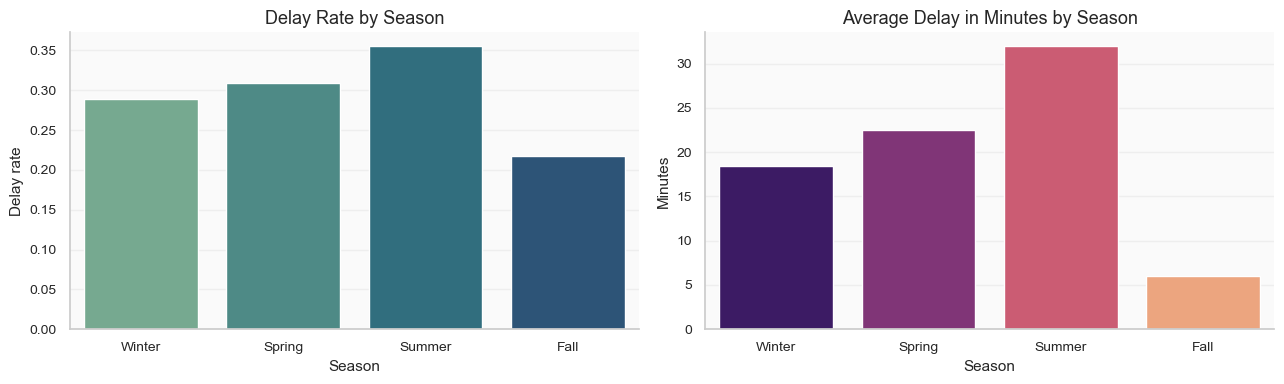

,Season,flights,delay_rate,avg_delay_minutes
0,Winter,312859,0.289539,18.496227
1,Spring,340192,0.308523,22.491549
2,Summer,350877,0.354931,31.944436
3,Fall,339515,0.216830,5.987161


In [16]:
seasonal = (
    df.groupby("Season", observed=True, as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("Season")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=seasonal, x="Season", y="delay_rate", ax=axes[0], palette="crest")
axes[0].set_title("Delay Rate by Season")
axes[0].set_ylabel("Delay rate")

sns.barplot(data=seasonal, x="Season", y="avg_delay_minutes", ax=axes[1], palette="magma")
axes[1].set_title("Average Delay in Minutes by Season")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

seasonal


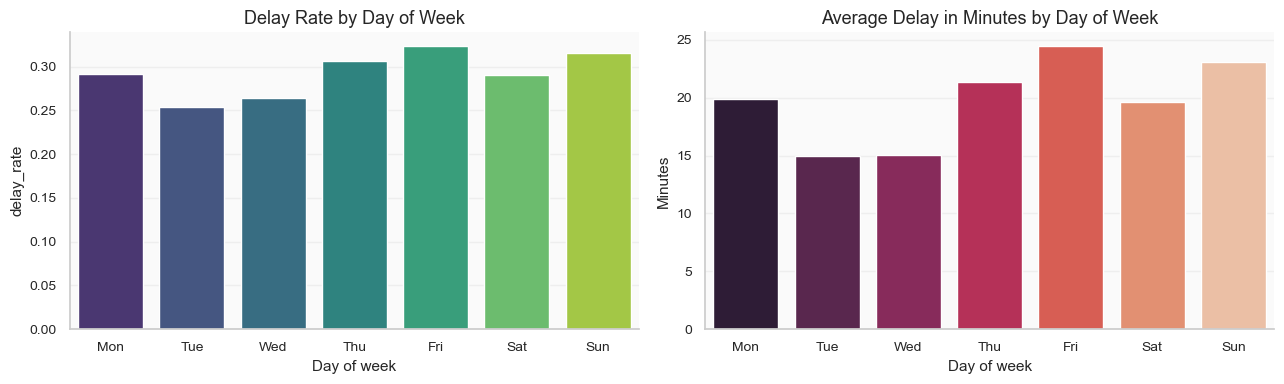

,weekday_name,flights,delay_rate,avg_delay_minutes
1,Mon,204257,0.291207,19.931048
5,Tue,185318,0.254169,14.926505
6,Wed,184812,0.264793,15.014425
4,Thu,197283,0.306575,21.313727
0,Fri,199956,0.323111,24.425624
2,Sat,173756,0.290534,19.642620
3,Sun,198061,0.316084,23.050949


In [17]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_perf = (
    df.groupby("weekday_name", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
)
weekday_perf["weekday_name"] = pd.Categorical(weekday_perf["weekday_name"], categories=weekday_order, ordered=True)
weekday_perf = weekday_perf.sort_values("weekday_name")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=weekday_perf, x="weekday_name", y="delay_rate", ax=axes[0], palette="viridis")
axes[0].set_title("Delay Rate by Day of Week")
axes[0].set_xlabel("Day of week")

sns.barplot(data=weekday_perf, x="weekday_name", y="avg_delay_minutes", ax=axes[1], palette="rocket")
axes[1].set_title("Average Delay in Minutes by Day of Week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

weekday_perf


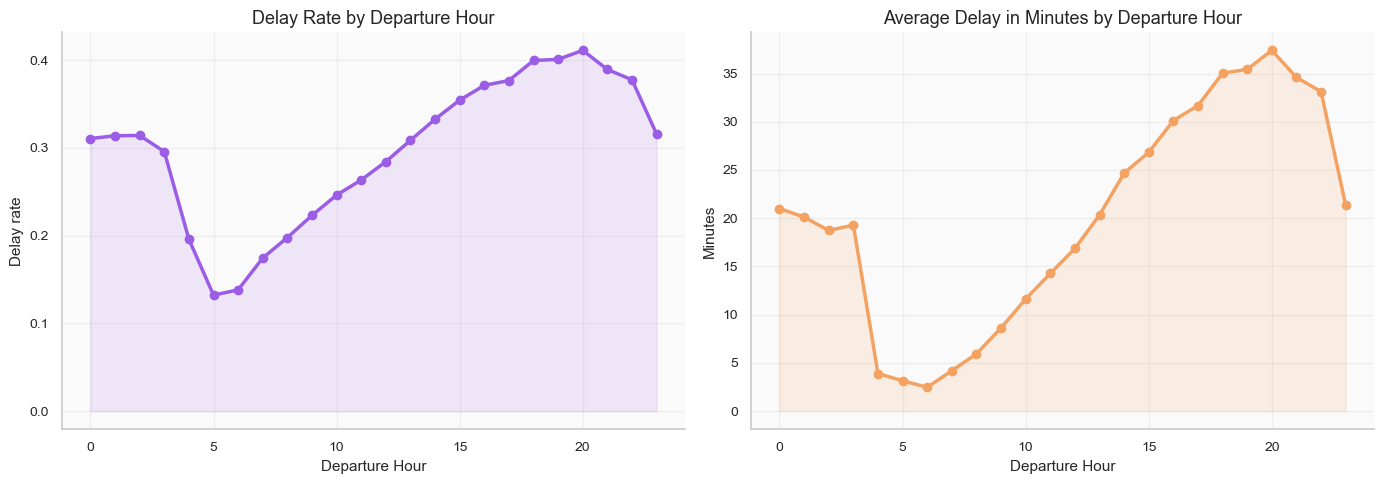

,Departure_Hour,flights,delay_rate,avg_delay_minutes
0,0,2356,0.310696,21.007216
1,1,787,0.313850,20.111817
2,2,331,0.314199,18.737160
3,3,213,0.295775,19.286385
4,4,97,0.195876,3.896907
5,5,38945,0.132263,3.159507
6,6,96233,0.138310,2.478859
7,7,94946,0.174626,4.196659
8,8,91803,0.197848,5.945220
9,9,75239,0.223116,8.630019


In [18]:
hourly = (
    df.groupby("Departure_Hour", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("Departure_Hour")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly["Departure_Hour"], hourly["delay_rate"], marker="o", linewidth=2.5, color=PURPLE)
axes[0].fill_between(hourly["Departure_Hour"], hourly["delay_rate"], color=PURPLE, alpha=0.12)
axes[0].set_title("Delay Rate by Departure Hour")
axes[0].set_xlabel("Departure Hour")
axes[0].set_ylabel("Delay rate")

axes[1].plot(hourly["Departure_Hour"], hourly["avg_delay_minutes"], marker="o", linewidth=2.5, color=ORANGE)
axes[1].fill_between(hourly["Departure_Hour"], hourly["avg_delay_minutes"], color=ORANGE, alpha=0.15)
axes[1].set_title("Average Delay in Minutes by Departure Hour")
axes[1].set_xlabel("Departure Hour")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

hourly


### Weekday × departure-hour delay heatmap

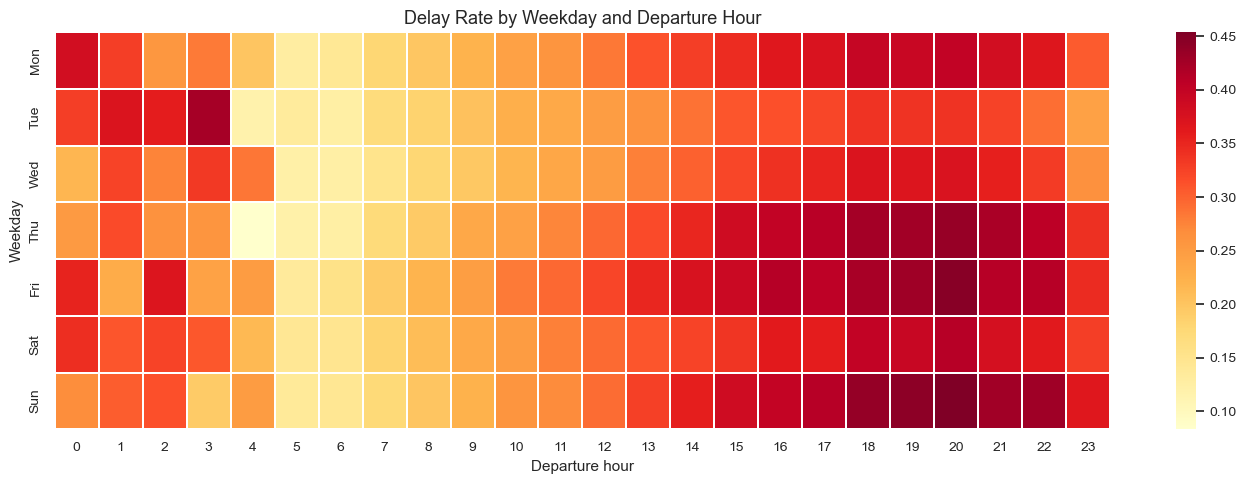

In [19]:
# Weekday × Departure Hour Heatmap of Delay Rate

weekday_hour_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

heat_df = df.dropna(subset=["weekday_name", "Departure_Hour", "IS_Delay"]).copy()
heat_df["Departure_Hour"] = pd.to_numeric(heat_df["Departure_Hour"], errors="coerce")
heat_df = heat_df.dropna(subset=["Departure_Hour"])
heat_df["Departure_Hour"] = heat_df["Departure_Hour"].astype(int)

pivot_delay = (
    heat_df.groupby(["weekday_name", "Departure_Hour"])["IS_Delay"]
    .mean()
    .reset_index()
    .pivot(index="weekday_name", columns="Departure_Hour", values="IS_Delay")
)

pivot_delay = pivot_delay.reindex(weekday_hour_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_delay, cmap="YlOrRd", linewidths=0.3)
plt.title("Delay Rate by Weekday and Departure Hour")
plt.xlabel("Departure hour")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()


**Operational insight:** This heatmap adds a more operational view than separate weekday and hour charts by showing *when* delay risk concentrates across the week. It helps identify whether certain weekday-hour combinations, such as late afternoons or end-of-week periods, are consistently more disruption-prone.

## 6. Airline performance comparison

This section compares airlines on:

- flight volume
- delay rate
- average delay minutes
- on-time rate

Because the project is about **delay in general**, airline analysis is presented with business-friendly full airline names instead of carrier codes where possible.


In [20]:
airline_perf = (
    df.groupby(["op_unique_carrier", "airline_name"], as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("flights", ascending=False)
)
airline_perf["on_time_rate"] = 1 - airline_perf["delay_rate"]

airline_perf


,op_unique_carrier,airline_name,flights,delay_rate,avg_delay_minutes,on_time_rate
13,WN,Southwest Airlines,267126,0.331368,16.780920,0.668632
4,DL,Delta Air Lines,191481,0.248865,13.738026,0.751135
1,AA,American Airlines,185345,0.347287,35.693167,0.652713
12,UA,United Airlines,143976,0.275108,18.255084,0.724892
11,OO,SkyWest Airlines,141277,0.247769,18.754256,0.752231
14,YX,Republic Airways,57421,0.180909,1.946344,0.819091
8,MQ,Envoy Air,51791,0.284605,16.798266,0.715395
9,NK,Spirit Airlines,51555,0.328077,23.735991,0.671923
2,AS,Alaska Airlines,47355,0.316355,12.116566,0.683645
3,B6,JetBlue Airways,47098,0.333454,28.255722,0.666546


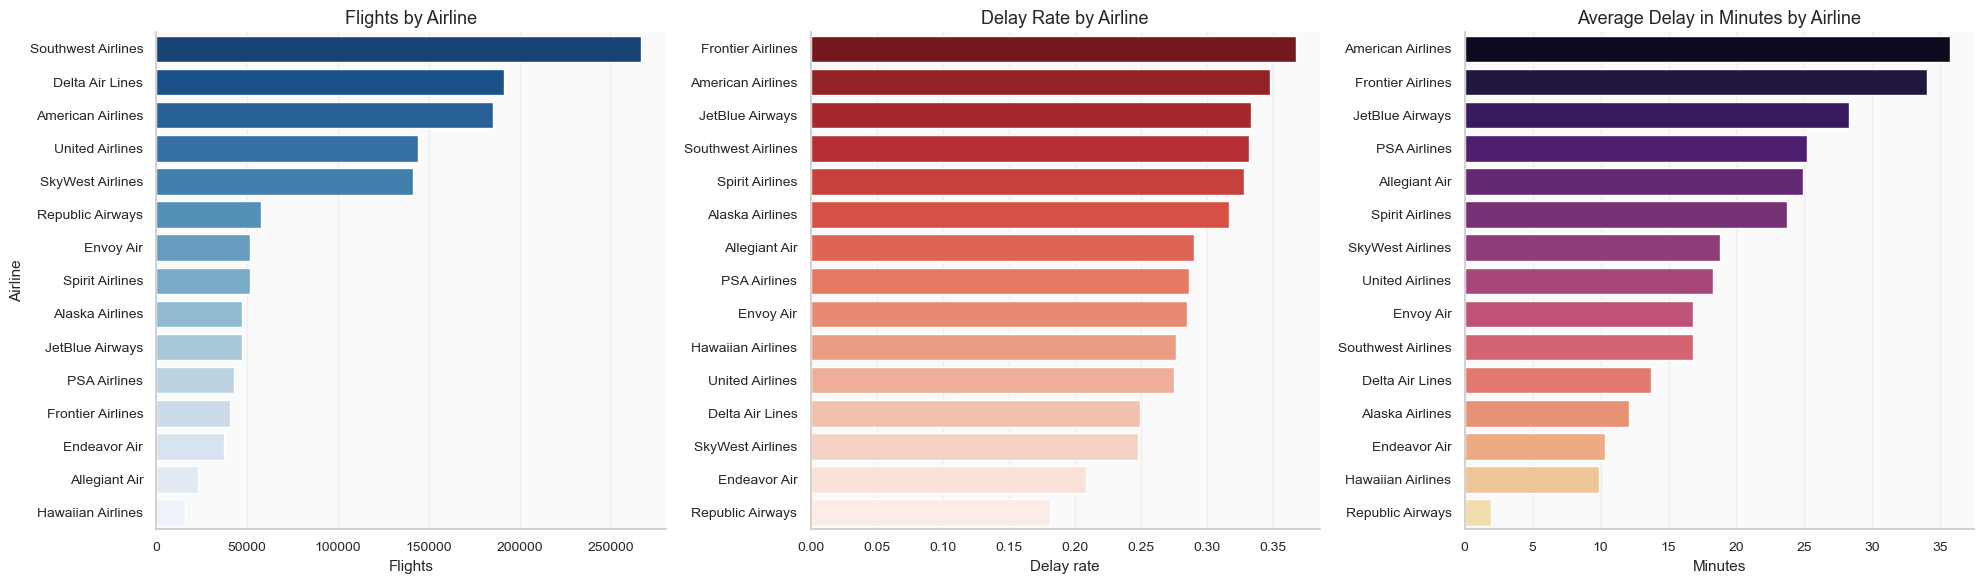

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=airline_perf.sort_values("flights", ascending=False), y="airline_name", x="flights", ax=axes[0], palette="Blues_r")
axes[0].set_title("Flights by Airline")
axes[0].set_xlabel("Flights")
axes[0].set_ylabel("Airline")

sns.barplot(data=airline_perf.sort_values("delay_rate", ascending=False), y="airline_name", x="delay_rate", ax=axes[1], palette="Reds_r")
axes[1].set_title("Delay Rate by Airline")
axes[1].set_xlabel("Delay rate")
axes[1].set_ylabel("")

sns.barplot(data=airline_perf.sort_values("avg_delay_minutes", ascending=False), y="airline_name", x="avg_delay_minutes", ax=axes[2], palette="magma")
axes[2].set_title("Average Delay in Minutes by Airline")
axes[2].set_xlabel("Minutes")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


In [22]:
# More defensible ranking: impose a minimum volume threshold
min_airline_flights = 5000
airline_ranked = airline_perf[airline_perf["flights"] >= min_airline_flights].copy()

airline_ranked.sort_values(["delay_rate", "avg_delay_minutes"], ascending=[True, True]).head(10)[
    ["airline_name", "flights", "on_time_rate", "delay_rate", "avg_delay_minutes"]
]


,airline_name,flights,on_time_rate,delay_rate,avg_delay_minutes
14,Republic Airways,57421,0.819091,0.180909,1.946344
0,Endeavor Air,37416,0.791399,0.208601,10.306607
11,SkyWest Airlines,141277,0.752231,0.247769,18.754256
4,Delta Air Lines,191481,0.751135,0.248865,13.738026
12,United Airlines,143976,0.724892,0.275108,18.255084
7,Hawaiian Airlines,15560,0.723458,0.276542,9.890938
8,Envoy Air,51791,0.715395,0.284605,16.798266
10,PSA Airlines,42544,0.713638,0.286362,25.188793
6,Allegiant Air,22931,0.710174,0.289826,24.895556
2,Alaska Airlines,47355,0.683645,0.316355,12.116566


### Airline reliability rank by month

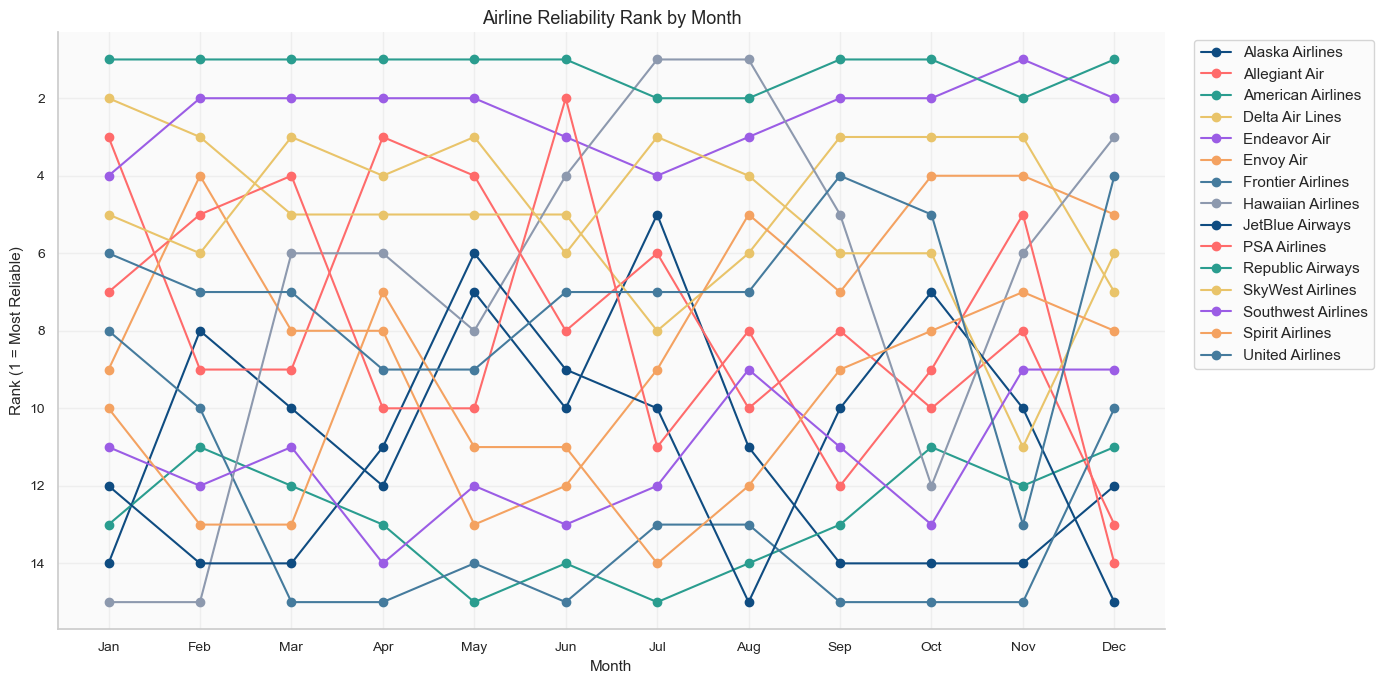

In [23]:
# Airline Reliability Rank by Month
# Lower delay rate = better rank

month_order_num = list(range(1, 13))
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

airline_month = (
    df.dropna(subset=["month", "airline_name", "IS_Delay"])
      .groupby(["month", "airline_name"])
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean")
      )
      .reset_index()
)

valid_airlines = (
    airline_month.groupby("airline_name")["flights"]
    .sum()
    .loc[lambda x: x >= 5000]
    .index
)

airline_month = airline_month[airline_month["airline_name"].isin(valid_airlines)].copy()

airline_month["rank"] = (
    airline_month.groupby("month")["delay_rate"]
    .rank(method="dense", ascending=True)
)

plt.figure(figsize=(14, 7))

for airline in sorted(airline_month["airline_name"].unique()):
    sub = airline_month[airline_month["airline_name"] == airline].sort_values("month")
    plt.plot(sub["month"], sub["rank"], marker="o", label=airline)

plt.gca().invert_yaxis()
plt.xticks(month_order_num, [month_labels[m] for m in month_order_num])
plt.title("Airline Reliability Rank by Month")
plt.xlabel("Month")
plt.ylabel("Rank (1 = Most Reliable)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Airline insight:** This ranking view shows whether airline reliability is stable throughout the year or changes with seasonal pressure. Airlines that remain near the top are operationally more consistent, while large rank swings suggest uneven month-to-month performance.

**Airline reliability insight:** Using full airline names and a minimum flight threshold makes the comparison more defensible.  
This section is especially useful for your Power BI and SQL deliverables because it translates raw operations into a clear reliability ranking.

## 7. Origin-focused airport and city analysis

This section emphasizes **origin-side patterns** because delays are operationally most actionable at the point where flights depart.


In [24]:
origin_perf = (
    df.groupby("origin_city", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("flights", ascending=False)
)

dest_perf = (
    df.groupby("dest_city", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("flights", ascending=False)
)


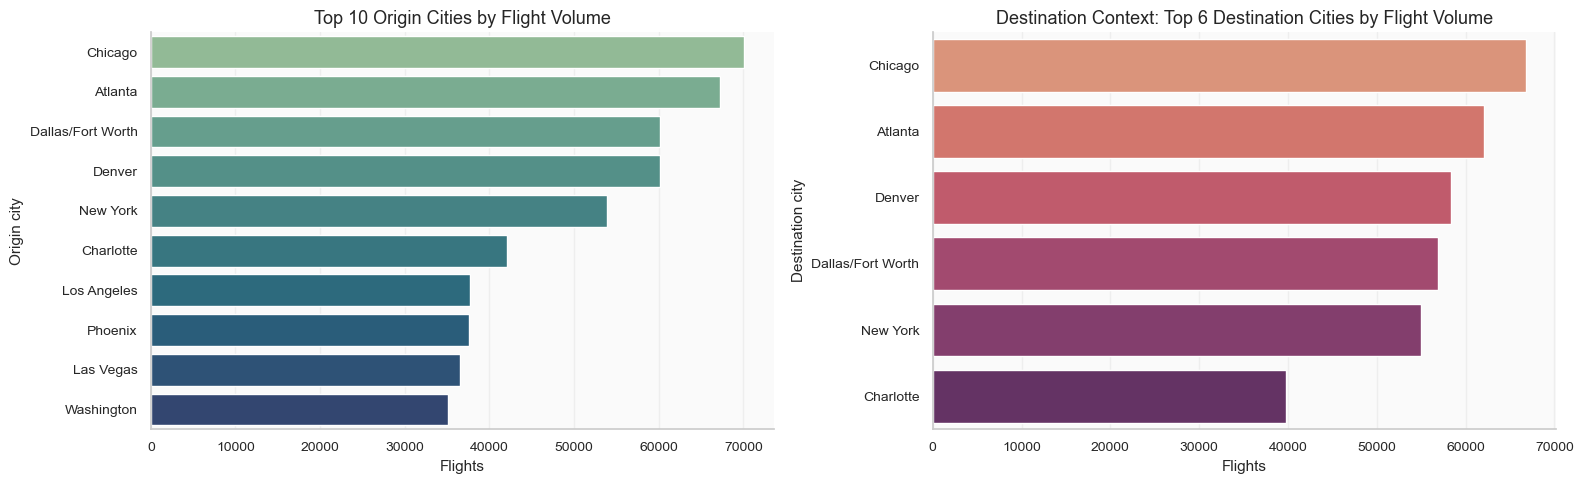

In [25]:
top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=origin_perf.head(top_n), y="origin_city", x="flights", ax=axes[0], palette="crest")
axes[0].set_title(f"Top {top_n} Origin Cities by Flight Volume")
axes[0].set_xlabel("Flights")
axes[0].set_ylabel("Origin city")

dest_context = dest_perf.head(6)
sns.barplot(data=dest_context, y="dest_city", x="flights", ax=axes[1], palette="flare")
axes[1].set_title("Destination Context: Top 6 Destination Cities by Flight Volume")
axes[1].set_xlabel("Flights")
axes[1].set_ylabel("Destination city")

plt.tight_layout()
plt.show()


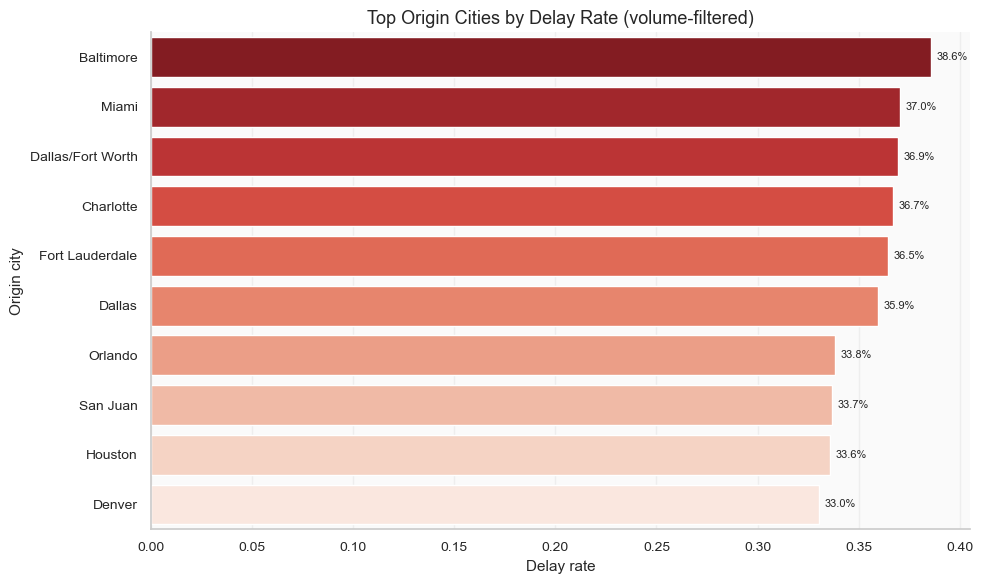

,dest_city,flights,delay_rate,avg_delay_minutes
273,San Francisco,26013,0.382078,29.243378
275,San Juan,7002,0.379035,30.397744
104,Fort Lauderdale,17932,0.343130,25.933025
272,San Diego,18036,0.340874,20.807496
323,West Palm Beach/Palm Beach,5724,0.338574,25.186059


In [26]:
min_city_flights = 3000

origin_ranked = (
    origin_perf[origin_perf["flights"] >= min_city_flights]
    .sort_values("delay_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=origin_ranked, y="origin_city", x="delay_rate", palette="Reds_r")
plt.title("Top Origin Cities by Delay Rate (volume-filtered)")
plt.xlabel("Delay rate")
plt.ylabel("Origin city")

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1%}", (p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)

plt.tight_layout()
plt.show()

dest_context_ranked = (
    dest_perf[dest_perf["flights"] >= min_city_flights]
    .sort_values("delay_rate", ascending=False)
    .head(5)
)

display(dest_context_ranked)


### Which origin airports/cities contribute the most delayed flights?
For presentation purposes, this section looks at **absolute delayed flight counts** from the origin side. This is different from delay rate: it highlights the places that contribute the largest number of delayed departures overall.


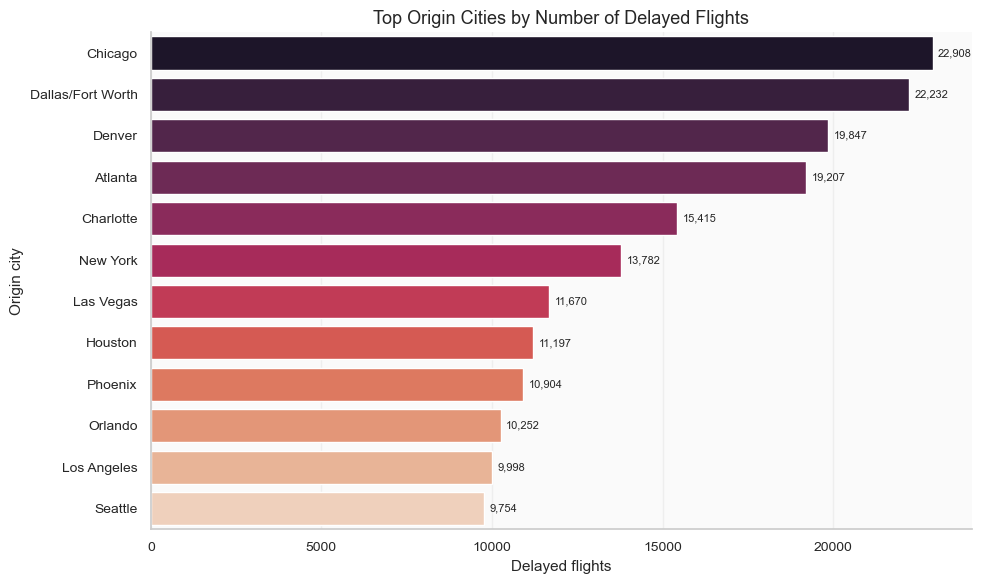

,origin_city,delayed_flights
60,Chicago,22908
74,Dallas/Fort Worth,22232
79,Denver,19847
17,Atlanta,19207
55,Charlotte,15415
218,New York,13782
173,Las Vegas,11670
137,Houston,11197
240,Phoenix,10904
230,Orlando,10252


In [27]:
origin_delay_counts = (
    df[df["IS_Delay"] == 1]
      .groupby("origin_city", as_index=False)
      .size()
      .rename(columns={"size": "delayed_flights"})
      .sort_values("delayed_flights", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=origin_delay_counts.head(12), y="origin_city", x="delayed_flights", palette="rocket")
plt.title("Top Origin Cities by Number of Delayed Flights")
plt.xlabel("Delayed flights")
plt.ylabel("Origin city")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y()+p.get_height()/2), xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)
plt.tight_layout()
plt.show()

origin_delay_counts.head(12)


### Volume vs delay-rate view for major origin cities
This bubble chart is useful because it balances **size** and **reliability**. Large circles indicate busier origin cities; positions further right and higher up indicate locations with stronger delay burden.


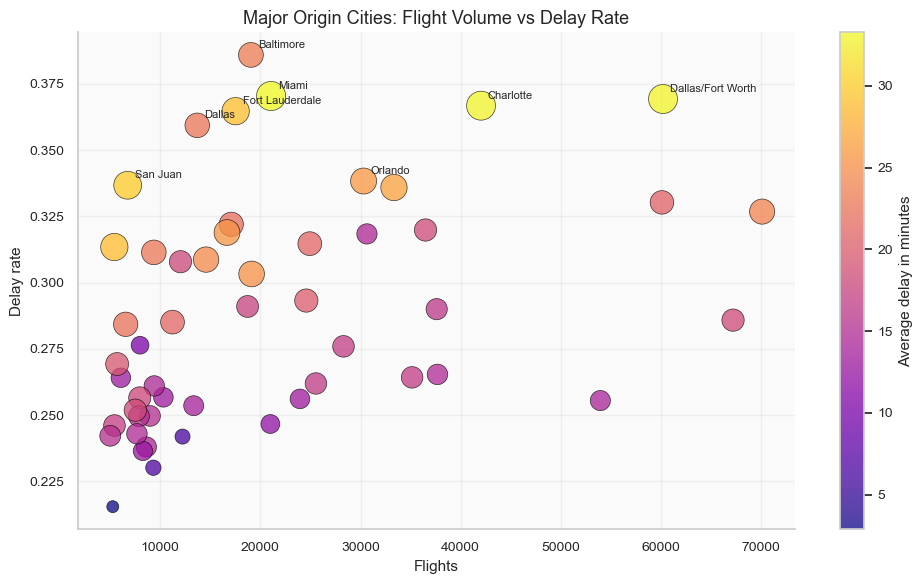

In [28]:
major_origins = origin_perf[origin_perf["flights"] >= 5000].copy()
major_origins["avg_delay_positive"] = major_origins["avg_delay_minutes"].clip(lower=0)

plt.figure(figsize=(10, 6))
plt.scatter(
    major_origins["flights"],
    major_origins["delay_rate"],
    s=major_origins["avg_delay_positive"] * 12 + 40,
    c=major_origins["avg_delay_positive"],
    cmap="plasma",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5
)

for _, row in major_origins.sort_values("delay_rate", ascending=False).head(8).iterrows():
    plt.annotate(row["origin_city"], (row["flights"], row["delay_rate"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

cbar = plt.colorbar()
cbar.set_label("Average delay in minutes")
plt.title("Major Origin Cities: Flight Volume vs Delay Rate")
plt.xlabel("Flights")
plt.ylabel("Delay rate")
plt.tight_layout()
plt.show()


**Origin insight:** High-volume origin cities matter more than isolated outliers because they combine operational scale with measurable delay risk.  
For the dashboard and SQL layer, origin-side delay rate and delayed-flight count are likely to be stronger operational KPIs than destination-side rankings alone.

## 8. Route-level analysis

Route analysis helps determine whether delay concentration is tied to specific city-pairs rather than only to individual origins or destinations.

To keep the results credible, routes are ranked with a minimum flight threshold.

In [29]:
route_perf = (
    df.groupby("route", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_delay_minutes=("delay_in_minutes", "mean")
      )
      .sort_values("flights", ascending=False)
)

route_perf.head(10)


,route,flights,delay_rate,avg_delay_minutes
1100,Chicago → New York,3121,0.326498,26.906120
3746,New York → Chicago,2910,0.255670,19.682818
651,Boston → New York,2712,0.236726,11.196903
3736,New York → Boston,2593,0.249518,19.164288
2376,Honolulu → Kahului,2383,0.204364,2.788082
277,Atlanta → New York,2343,0.316688,22.888178
3111,Los Angeles → San Francisco,2295,0.399129,26.425272
3729,New York → Atlanta,2272,0.297535,19.965229
2658,Kahului → Honolulu,2271,0.213122,1.806253
678,Boston → Washington,2217,0.216960,12.159224


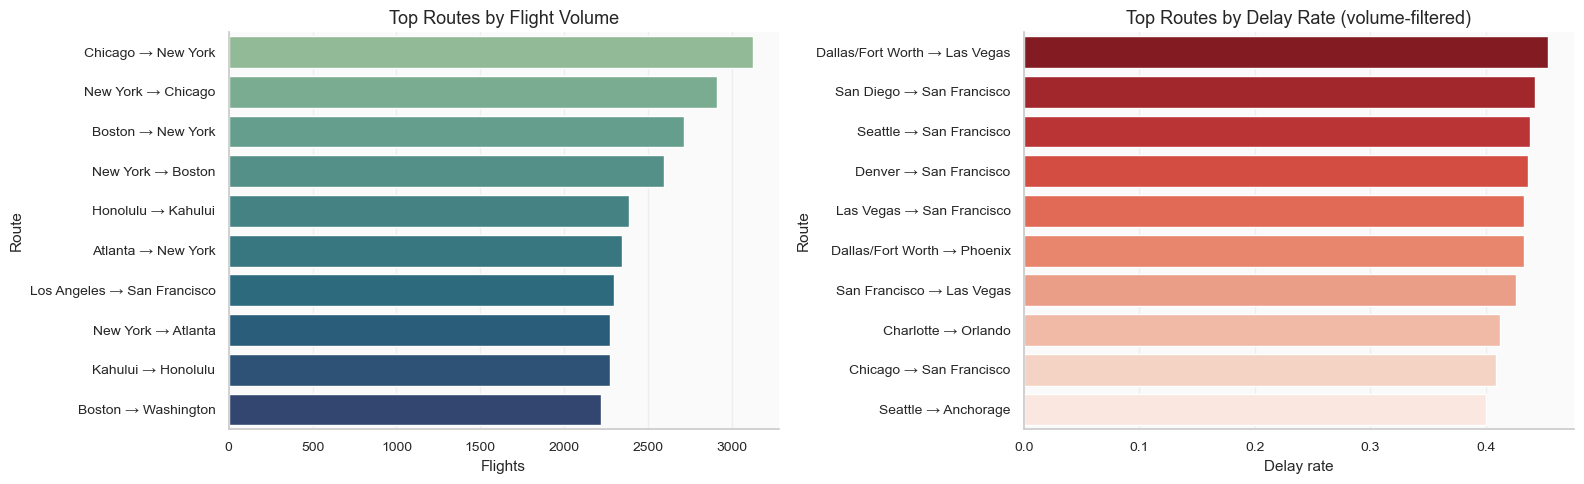

In [30]:
min_route_flights = 1000
route_ranked = route_perf[route_perf["flights"] >= min_route_flights].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=route_ranked.sort_values("flights", ascending=False).head(10), y="route", x="flights", ax=axes[0], palette="crest")
axes[0].set_title("Top Routes by Flight Volume")
axes[0].set_xlabel("Flights")
axes[0].set_ylabel("Route")

sns.barplot(data=route_ranked.sort_values("delay_rate", ascending=False).head(10), y="route", x="delay_rate", ax=axes[1], palette="Reds_r")
axes[1].set_title("Top Routes by Delay Rate (volume-filtered)")
axes[1].set_xlabel("Delay rate")
axes[1].set_ylabel("Route")

plt.tight_layout()
plt.show()


## 9. Delay reason analysis

Delay reason columns help explain **why delay burden builds up**, not just how often flights are late.

This section compares:
- `carrier_delay`
- `weather_delay`
- `nas_delay`
- `security_delay`
- `late_aircraft_delay`

These operational reason fields are useful because they show whether delay burden is driven more by airline operations, system congestion, or other disruption categories.


In [31]:
delay_reason_cols = [
    "carrier_delay", "weather_delay", "nas_delay",
    "security_delay", "late_aircraft_delay"
]

reason_minutes = df[delay_reason_cols].sum().sort_values(ascending=False).rename("total_minutes")
reason_share = (reason_minutes / reason_minutes.sum()).rename("share_of_reason_minutes")

pd.concat([reason_minutes, reason_share], axis=1)


,total_minutes,share_of_reason_minutes
late_aircraft_delay,8134381,0.404492
carrier_delay,6969261,0.346555
nas_delay,3759541,0.186948
weather_delay,1212904,0.060313
security_delay,34029,0.001692


In [32]:
reason_positive_counts = (df[delay_reason_cols] > 0).sum().sort_values(ascending=False).rename("flights_affected")
reason_positive_rate = (df[delay_reason_cols].gt(0).mean()).sort_values(ascending=False).rename("share_of_flights")

pd.concat([reason_positive_counts, reason_positive_rate], axis=1)


,flights_affected,share_of_flights
carrier_delay,152561,0.113560
late_aircraft_delay,142778,0.106278
nas_delay,138346,0.102979
weather_delay,17412,0.012961
security_delay,1459,0.001086


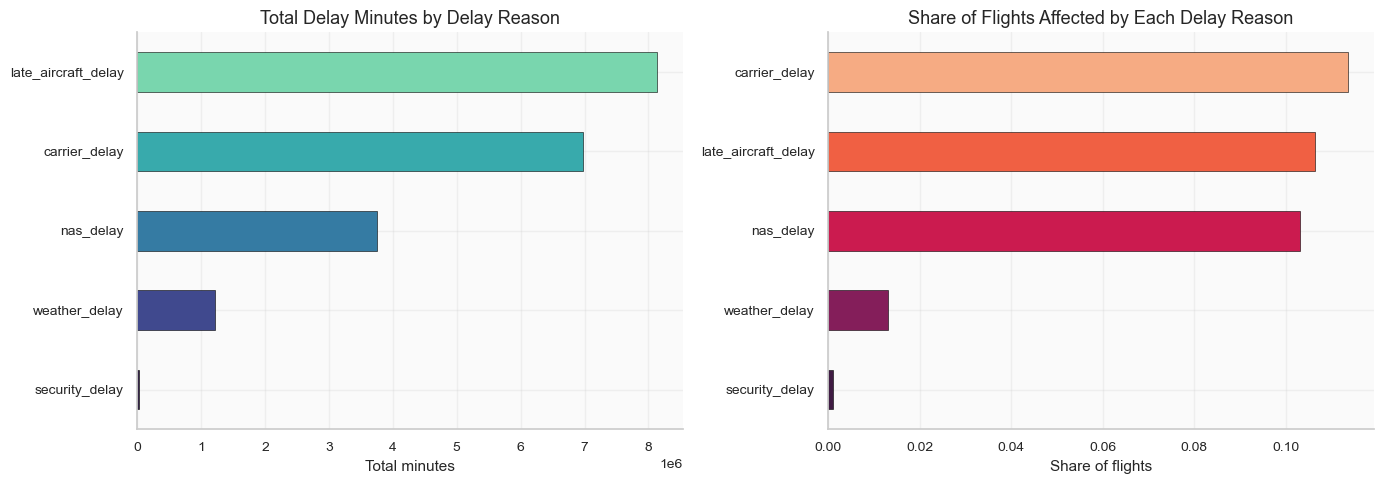

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reason_minutes.sort_values().plot(kind="barh", ax=axes[0], color=sns.color_palette("mako", 5), edgecolor='black', linewidth=0.4)
axes[0].set_title("Total Delay Minutes by Delay Reason")
axes[0].set_xlabel("Total minutes")

reason_positive_rate.sort_values().plot(kind="barh", ax=axes[1], color=sns.color_palette("rocket", 5), edgecolor='black', linewidth=0.4)
axes[1].set_title("Share of Flights Affected by Each Delay Reason")
axes[1].set_xlabel("Share of flights")

plt.tight_layout()
plt.show()


**Delay-cause insight:** Looking only at totals can hide *when* each delay reason matters most.  
A monthly composition view adds a stronger operational story by showing whether some parts of the year are dominated by carrier, NAS, late-aircraft, or weather-related minutes.


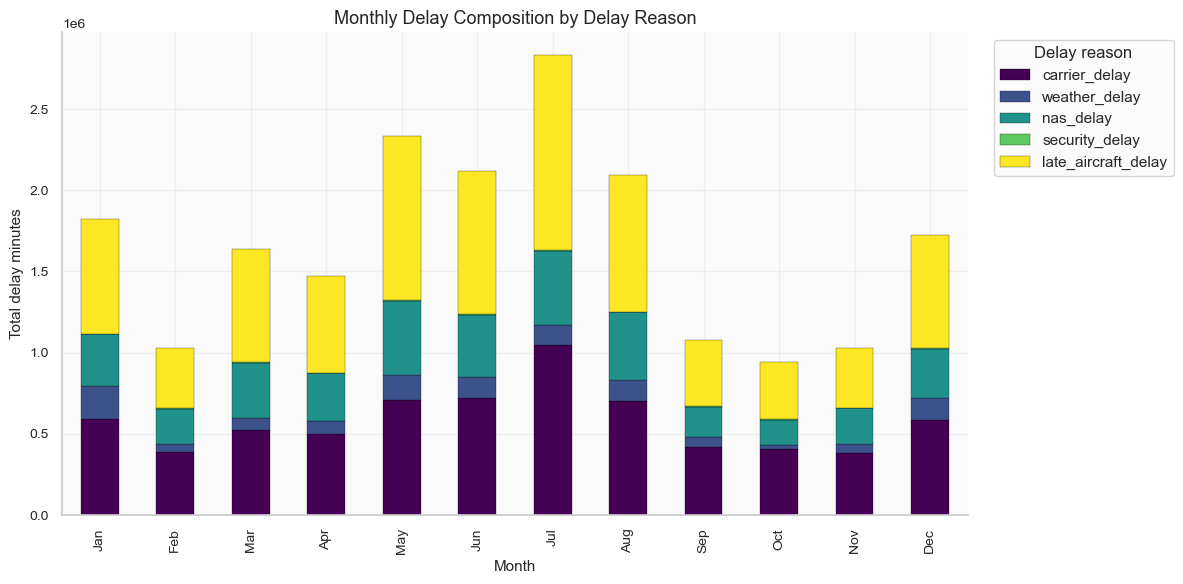

In [34]:
monthly_reason = (
    df.groupby("month")[delay_reason_cols]
      .sum()
      .reindex(range(1, 13))
)

monthly_reason.index = month_order

monthly_reason.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis", edgecolor="black", linewidth=0.2)
plt.title("Monthly Delay Composition by Delay Reason")
plt.xlabel("Month")
plt.ylabel("Total delay minutes")
plt.legend(title="Delay reason", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 10. Relationships among key flight variables

This section keeps the numeric relationship view **flight-focused**.  
It checks how overall delay severity relates to:

- departure timing
- scheduled and actual elapsed-time variables
- air time
- the binary delay target itself

This provides a cleaner bridge to later modeling without drifting away from the flight-side story.


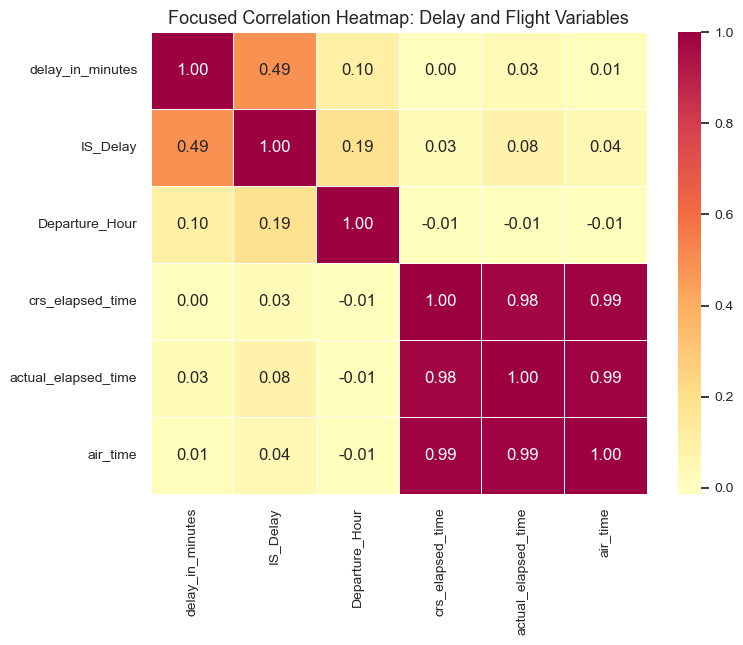

In [35]:
corr_cols = [
    "delay_in_minutes", "IS_Delay", "Departure_Hour",
    "crs_elapsed_time", "actual_elapsed_time", "air_time"
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="Spectral_r", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Focused Correlation Heatmap: Delay and Flight Variables")
plt.show()


**Correlation note:** This smaller heatmap is intentionally limited to flight-side variables so the relationship view stays clean, relevant, and presentation-friendly.  
It is useful for explanation, but realized post-flight variables would still need caution if used later in predictive modeling.


## 11. Additional operational insight: elapsed-time stretch

This section compares scheduled and actual elapsed time to show whether flights that run longer than planned are also linked with heavier delay burden.



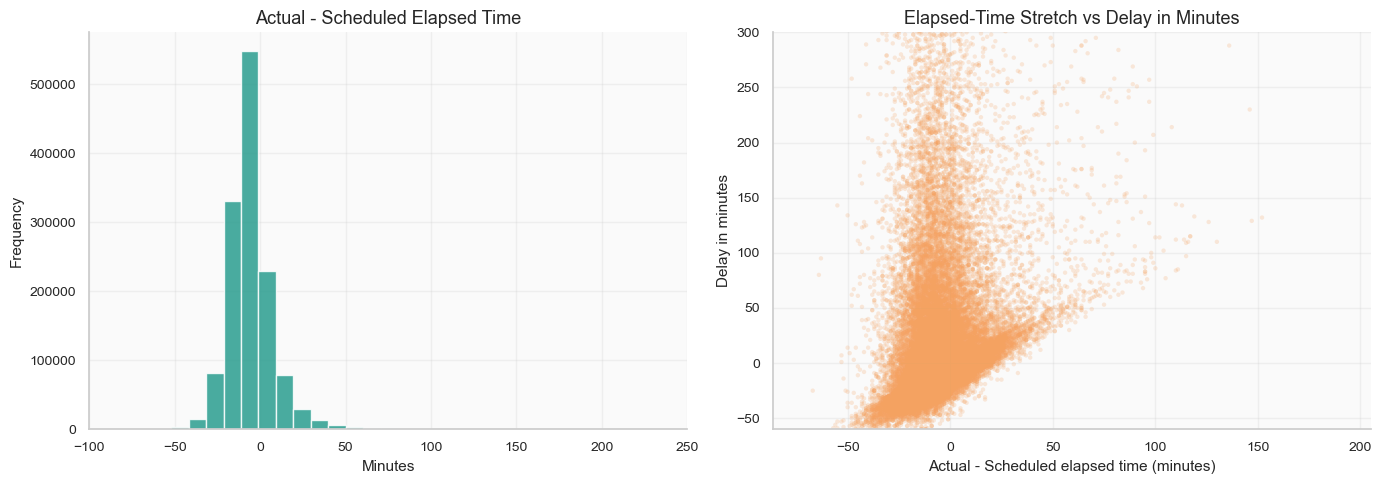

In [36]:
elapsed_diff = df["actual_elapsed_time"] - df["crs_elapsed_time"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(elapsed_diff.dropna(), bins=80, color=GREEN, alpha=0.85, edgecolor='white')
axes[0].set_title("Actual - Scheduled Elapsed Time")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(-100, 250)

stretch_delay = df.loc[operated_mask, ["delay_in_minutes", "actual_elapsed_time", "crs_elapsed_time"]].dropna().copy()
stretch_delay["elapsed_stretch"] = stretch_delay["actual_elapsed_time"] - stretch_delay["crs_elapsed_time"]

sample_n = min(50000, len(stretch_delay))
sample2 = stretch_delay.sample(sample_n, random_state=42)

axes[1].scatter(sample2["elapsed_stretch"], sample2["delay_in_minutes"], alpha=0.22, s=10, color=ORANGE, edgecolors='none')
axes[1].set_title("Elapsed-Time Stretch vs Delay in Minutes")
axes[1].set_xlabel("Actual - Scheduled elapsed time (minutes)")
axes[1].set_ylabel("Delay in minutes")
axes[1].set_ylim(-60, 300)

plt.tight_layout()
plt.show()


## 12. Unique operational view: daily delay heatmap

This heatmap highlights how delay burden moves across the year at the **daily** level. It is a compact way to spot clusters, spikes, and seasonal concentration that can disappear inside monthly averages.


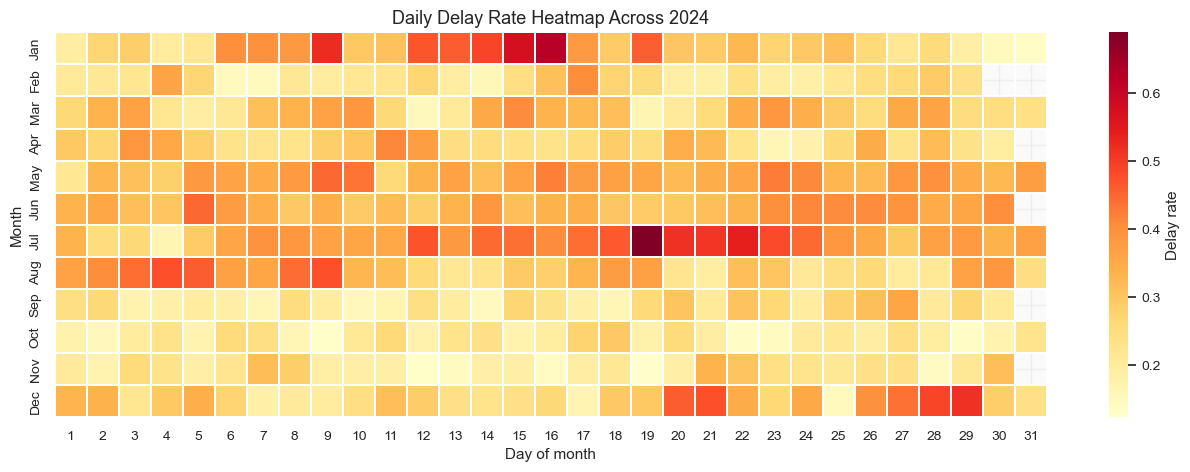

In [37]:
daily_delay = (
    df.dropna(subset=["fl_date"])
      .groupby("fl_date", as_index=False)
      .agg(delay_rate=("IS_Delay", "mean"))
      .sort_values("fl_date")
)

daily_delay["month_name"] = daily_delay["fl_date"].dt.strftime("%b")
daily_delay["day"] = daily_delay["fl_date"].dt.day

calendar_heat = daily_delay.pivot(index="month_name", columns="day", values="delay_rate")
calendar_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
calendar_heat = calendar_heat.reindex(calendar_order)

plt.figure(figsize=(16, 5))
sns.heatmap(calendar_heat, cmap="YlOrRd", linewidths=0.2, linecolor="white", cbar_kws={"label": "Delay rate"})
plt.title("Daily Delay Rate Heatmap Across 2024")
plt.xlabel("Day of month")
plt.ylabel("Month")
plt.show()


**Calendar insight:** This daily view makes it easier to spot concentrated periods of disruption that can disappear inside monthly averages.  
If one date becomes dramatically darker than the rest, that can be flagged in the presentation as a likely systemwide disruption day rather than a normal operational fluctuation.


## 13. Limitations and interpretation boundaries

A strong EDA should also state its limits clearly.

### Key limitations in this file
- `IS_Delay` is based on **delay > 15 minutes**, which is useful for modeling and KPI reporting, but it simplifies disruption into a binary outcome.
- The final merged file used here contains **no cancellation variation**, so cancellation analysis is not a meaningful focus in this notebook.
- Rankings for airlines, cities, and routes can be misleading when group sizes are tiny, so minimum-volume thresholds are used where possible.
- Some realized delay fields and delay-reason fields are analytically useful for EDA, but they would create leakage if used as model inputs.
- This notebook is intentionally **flight-focused**, so detailed weather-impact EDA is left to the separate teammate workstream.


## 14. Final summary and transition to modeling

### What this notebook establishes
- delay is common enough and structured enough to analyze seriously
- delay burden varies meaningfully across month, week, weekday, and departure hour
- airline and origin patterns reveal clear reliability differences
- route-level concentration helps identify where delay burden is operationally largest
- delay reasons add explanatory depth beyond simple delay counts
- the daily heatmap helps surface unusually disruptive dates that deserve attention in presentation and discussion

### Modeling bridge

Based on this flight-side EDA, the next stage can focus on predicting `IS_Delay` using variables available prior to departure, such as:

- airline
- departure hour
- month / week / season / weekday
- origin and destination information
- planned elapsed-time variables

That creates a clean handoff from descriptive operations analysis to predictive delay modeling.
